# ViT-B/16 WaRP-C Industrial Waste Classification



In [ ]:
# !pip install timm seaborn scikit-learn -q

In [ ]:
!unzip -q "/content/WaRP-C-preprocessed.zip" -d /content/

In [ ]:
import os, io, math, time, random, copy
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
)
from sklearn.preprocessing import label_binarize



In [ ]:
# Configuration
TRAIN_FOLDER = "/content/train"
VAL_FOLDER   = "/content/val"
TEST_FOLDER  = "/content/test"
RESULTS_DIR  = "./results_improved"

# Model
MODEL_NAME = "vit_base_patch16_224"
IMAGE_SIZE = 224
NUMBER_OF_CLASSES = 28
DROP_PATH_RATE = 0.1

# Training
BATCH_SIZE = 16
GRAD_ACCUM_STEPS  = 4
NUMBER_OF_EPOCHS  = 30
BASE_LR = 3e-4
WEIGHT_DECAY = 0.05
LABEL_SMOOTHING = 0.1
WARMUP_EPOCHS = 6
LLRD_DECAY = 0.75

# Focal Loss
FOCAL_LOSS_GAMMA  = 2.0

# MixUp / CutMix
MIXUP_ALPHA  = 0.4
CUTMIX_ALPHA = 1.0
MIXUP_PROB   = 0.5

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(RESULTS_DIR, exist_ok=True)


In [ ]:
# DATASET
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class WaRPDataset28(Dataset):
    IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

    def __init__(self, root, transform=None):
        root = Path(root)
        self.transform = transform
        self.samples   = []

        subclass_folders = sorted([
            sub
            for superclass in sorted(root.iterdir()) if superclass.is_dir()
            for sub in sorted(superclass.iterdir()) if sub.is_dir()
        ])

        self.classes      = [s.name for s in subclass_folders]
        self.class_to_idx = {name: i for i, name in enumerate(self.classes)}

        for folder in subclass_folders:
            label = self.class_to_idx[folder.name]
            for img_path in sorted(folder.iterdir()):
                if img_path.suffix.lower() in self.IMG_EXTS:
                    self.samples.append((img_path, label))

        self.targets = [lbl for _, lbl in self.samples]

    def __len__(self):  return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform: image = self.transform(image)
        return image, label


# TRANSFORMS
train_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(p=0.2),
    T.RandAugment(num_ops=2, magnitude=9),   # NEW vs baseline
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    T.RandomRotation(degrees=20),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = WaRPDataset28(root=TRAIN_FOLDER, transform=train_transforms)
val_dataset= WaRPDataset28(root=VAL_FOLDER,   transform=eval_transforms)
test_dataset= WaRPDataset28(root=TEST_FOLDER,  transform=eval_transforms)
class_names = train_dataset.classes

assert train_dataset.classes == val_dataset.classes == test_dataset.classes
print(f"Classes : {len(class_names)}")
print(f"Train images: {len(train_dataset)}")
print(f"Val images  : {len(val_dataset)}")
print(f"Test images : {len(test_dataset)}")

Classes : 28
Train images: 7058
Val images  : 1765
Test images : 1551


Train batches : 442
Val batches   : 111
Test batches  : 97


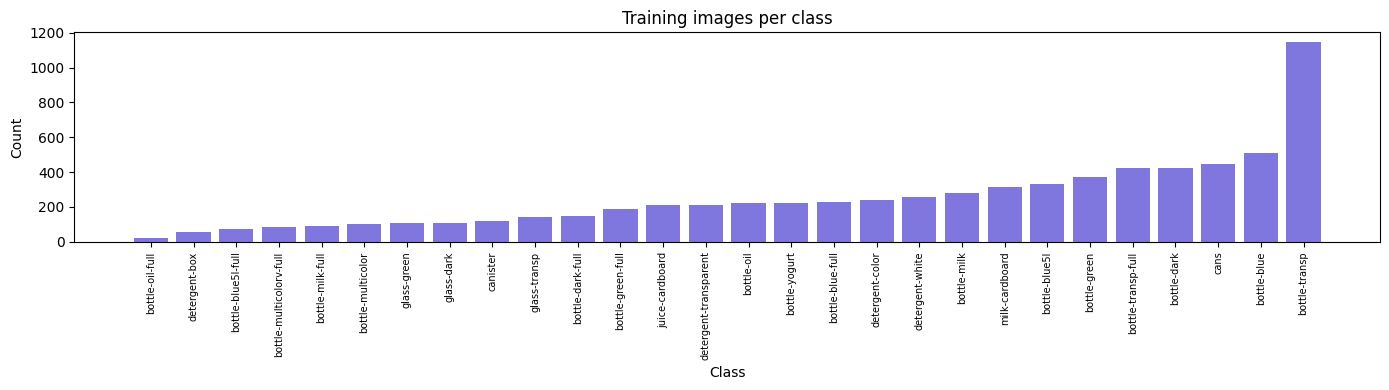

In [ ]:
# DATA LOADERS
images_per_class = Counter(train_dataset.targets)
sample_weights = [1.0 / images_per_class[lbl] for lbl in train_dataset.targets]

#WeightedRandomSampler for class imbalance
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=weighted_sampler, num_workers=2, pin_memory=True)
val_loader= DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,  num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

# Class distribution plot
sorted_cls = sorted(images_per_class.items(), key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar([class_names[i] for i, _ in sorted_cls],
       [c for _, c in sorted_cls], color='#7F77DD')
ax.set_title('Training images per class')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/class_distribution.png', dpi=150)
plt.show()

In [ ]:
# MODEL and LAYER-WISE LEARNING RATE DECAY (LLRD)
#LLRD assigns a decaying LR multiplier to each block so early layers are updated very conservatively
#Stochastic depth act as a strong regulariser similar to dropout
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUMBER_OF_CLASSES,
    drop_path_rate=DROP_PATH_RATE,
)
model = model.to(device)

def get_llrd_param_groups(model, base_lr, decay, wd):
    no_wd = {'bias', 'norm', 'LayerNorm'}
    groups = []

    # Head and patch embedding at full LR
    hp, hn = [], []
    for name, p in model.named_parameters():
        if 'head' in name or 'patch_embed' in name:
            (hn if any(nd in name for nd in no_wd) else hp).append(p)
    groups += [{'params': hp, 'lr': base_lr, 'weight_decay': wd},
               {'params': hn, 'lr': base_lr, 'weight_decay': 0.0}]

    # Transformer blocks with decaying LR
    n_blocks = len(model.blocks)
    for i in range(n_blocks - 1, -1, -1):
        blk_lr = base_lr * (decay ** (n_blocks - i))
        bp, bn = [], []
        for name, p in model.blocks[i].named_parameters():
            (bn if any(nd in name for nd in no_wd) else bp).append(p)
        groups += [{'params': bp, 'lr': blk_lr, 'weight_decay': wd},
                   {'params': bn, 'lr': blk_lr, 'weight_decay': 0.0}]
    return groups


param_groups = get_llrd_param_groups(model, BASE_LR, LLRD_DECAY, WEIGHT_DECAY)


In [ ]:
# FOCAL LOSS, OPTIMIZER, SCHEDULER
#   WaRP-C has strong class imbalance. Standard Cross entropy treats every sample
#   equally, so easy majority-class examples dominate the gradient.
#   Focal Loss multiplies each sample's CE loss by (1 - p_t)^gamma where p_t is the model's predicted probability for the correctclass of that sample.
#   Combined with class weights this gives strong handling of imbalance.

total_images  = len(train_dataset)
class_weights = torch.tensor([
    total_images / (NUMBER_OF_CLASSES * images_per_class[i])
    for i in range(NUMBER_OF_CLASSES)
], dtype=torch.float32).to(device)


class FocalLoss(nn.Module):

    def __init__(self, gamma=FOCAL_LOSS_GAMMA, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight# per-class balancing weights
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # Compute standard CE loss per sample
        ce_loss = F.cross_entropy(
            logits, targets,
            weight=self.weight,
            label_smoothing=self.label_smoothing,
            reduction='none'
        )
        #probability assigned to the true class
        p_t = torch.exp(-ce_loss)
        # Apply focusing factor (1 - p_t)^gamma
        focal_loss = (1.0 - p_t) ** self.gamma * ce_loss
        return focal_loss.mean()

loss_fn = FocalLoss(
    gamma=FOCAL_LOSS_GAMMA,
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)
optimiser = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

def warmup_cosine_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(WARMUP_EPOCHS)
    progress = float(epoch - WARMUP_EPOCHS) / max(1, NUMBER_OF_EPOCHS - WARMUP_EPOCHS)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimiser, warmup_cosine_lambda)


In [ ]:
# MIXUP and CUTMIX AUGMENTATION
#mix_up is blending two images and their labels
#It Forces smooth decision boundaries; robust to noisy inputs.
#Cutmix Pastes a random rectangular patch from image B onto image A.
#It Preserves local textures
#and also better for fine-grained classification where texture matters.

def mixup_batch(images, labels, alpha=MIXUP_ALPHA, nc=NUMBER_OF_CLASSES):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0)).to(images.device)
    mixed = lam * images + (1 - lam) * images[idx]
    y = lam * F.one_hot(labels, nc).float() + (1-lam) * F.one_hot(labels[idx], nc).float()
    return mixed, y

def cutmix_batch(images, labels, alpha=CUTMIX_ALPHA, nc=NUMBER_OF_CLASSES):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0)).to(images.device)
    _, _, H, W = images.size()
    cut_h = int(H * math.sqrt(1 - lam))
    cut_w = int(W * math.sqrt(1 - lam))
    cx, cy = random.randint(0, W), random.randint(0, H)
    x1, x2 = max(0, cx - cut_w//2), min(W, cx + cut_w//2)
    y1, y2 = max(0, cy - cut_h//2), min(H, cy + cut_h//2)
    mixed = images.clone()
    mixed[:, :, y1:y2, x1:x2] = images[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2-x1)*(y2-y1)/(W*H)
    y = lam * F.one_hot(labels, nc).float() + (1-lam) * F.one_hot(labels[idx], nc).float()
    return mixed, y

def soft_cross_entropy(logits, soft_targets, weight=None):
    log_probs = F.log_softmax(logits, dim=1)
    if weight is not None:
        log_probs = log_probs * weight.unsqueeze(0)
    return -(soft_targets * log_probs).sum(dim=1).mean()



In [ ]:
# TRAINING AND EVALUATION FUNCTIONS
#   Larger effective batches give more stable gradient estimates,
#   which helps the cosine schedule and LLRD work as intended, without
#   needing more GPU memory.
def train_one_epoch(model, loader, opt):
    model.train()
    total_loss = correct = total = 0
    opt.zero_grad()   # zero once at the start of the epoch

    for step, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        r = random.random()
        if r < MIXUP_PROB / 2:
            images, soft_y = mixup_batch(images, labels)
            logits = model(images)
            loss   = soft_cross_entropy(logits, soft_y, weight=class_weights)
        elif r < MIXUP_PROB:
            images, soft_y = cutmix_batch(images, labels)
            logits = model(images)
            loss   = soft_cross_entropy(logits, soft_y, weight=class_weights)
        else:
            logits = model(images)
            loss   = loss_fn(logits, labels)

        # Scale loss so gradients are averaged over accumulation steps
        (loss / GRAD_ACCUM_STEPS).backward()

        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)

        # Step update every GRAD_ACCUM_STEPS mini-batches
        if (step + 1) % GRAD_ACCUM_STEPS == 0 or (step + 1) == len(loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            opt.zero_grad()

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(mdl, loader):
    """Evaluate the model on a dataloader."""
    mdl.eval()
    total_loss = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = mdl(images)
        loss   = loss_fn(logits, labels)
        total_loss += loss.item() * images.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total



In [ ]:
# HYPERPARAMETER TUNING
!pip install optuna optuna-integration -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 11.7 MB/s eta 0:00:00


In [ ]:
# HYPERPARAMETER TUNING WITH OPTUNA
# Optuna uses TPE (Tree-structured Parzen Estimator) to intelligently
# search the hyperparameter space.
# Parameters searched:
#   base_lr
#   weight_decay
#   label_smoothing
#   llrd_decay
#   mixup_prob
#   mixup_alpha
#   dropout

import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress verbose Optuna output

# Search criteria
N_TRIALS  = 3   # number of HP combinations to evaluate
HP_EPOCHS = 2   # training epochs per trial
HP_WARMUP = 1   # warmup epochs within each trial


def build_trial_model(trial):
    """Build a fresh ViT with dropout rate sampled by Optuna for this trial."""
    drop = trial.suggest_float('dropout', 0.0, 0.4, step=0.1)
    m = timm.create_model(
        MODEL_NAME, pretrained=True,
        num_classes=NUMBER_OF_CLASSES,
        drop_rate=drop,
        drop_path_rate=drop * 0.5
    )
    return m.to(device)


def run_trial(trial):

    # Sample all hyperparameters for this trial
    lr= trial.suggest_float('base_lr',         1e-5, 5e-4, log=True)
    wd= trial.suggest_float('weight_decay',    1e-4, 0.2,  log=True)
    ls= trial.suggest_float('label_smoothing', 0.0,  0.2,  step=0.05)
    llrd= trial.suggest_float('llrd_decay',      0.5,  0.95, step=0.05)
    mix_prob = trial.suggest_float('mixup_prob',      0.0,  0.8,  step=0.1)
    mix_alpha= trial.suggest_float('mixup_alpha',     0.2,  1.0,  step=0.2)

    # Build model, optimizer, and scheduler for this trial's HPs
    trial_model  = build_trial_model(trial)
    trial_params = get_llrd_param_groups(trial_model, lr, llrd, wd)
    trial_opt    = torch.optim.AdamW(trial_params, weight_decay=wd)

    def _warmup_cos(epoch):
        # Miniature warmup and cosine schedule for the short trial run
        if epoch < HP_WARMUP:
            return (epoch + 1) / HP_WARMUP
        prog = (epoch - HP_WARMUP) / max(1, HP_EPOCHS - HP_WARMUP)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * prog)))

    trial_sched = torch.optim.lr_scheduler.LambdaLR(trial_opt, _warmup_cos)
    trial_loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=ls)

    # Short training loop
    for epoch in range(HP_EPOCHS):
        trial_model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            r = random.random()
            if r < mix_prob / 2:
                images, soft_y = mixup_batch(images, labels, alpha=mix_alpha, nc=NUMBER_OF_CLASSES)
                logits = trial_model(images)
                loss   = soft_cross_entropy(logits, soft_y, weight=class_weights)
            elif r < mix_prob:
                images, soft_y = cutmix_batch(images, labels, alpha=mix_alpha, nc=NUMBER_OF_CLASSES)
                logits = trial_model(images)
                loss   = soft_cross_entropy(logits, soft_y, weight=class_weights)
            else:
                logits = trial_model(images)
                loss   = trial_loss_fn(logits, labels)
            trial_opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trial_model.parameters(), 1.0)  # clip gradients
            trial_opt.step()
        trial_sched.step()

        # Compute validation accuracy after each epoch
        trial_model.eval()
        correct = total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                preds   = trial_model(images).argmax(1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_acc = correct / total

        # Report to Optuna and allows pruning of bad trials early
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    del trial_model
    torch.cuda.empty_cache()
    return val_acc

# Create and run the Optuna study
print(f"Starting Optuna HP search: {N_TRIALS} trials x {HP_EPOCHS} epochs each")
study = optuna.create_study(
    direction='maximize',# we want to maximise validation accuracy
    sampler=TPESampler(seed=RANDOM_SEED), # TPE sampler for intelligent search
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=3, n_warmup_steps=2
    ),
)
study.optimize(run_trial, n_trials=N_TRIALS, show_progress_bar=True)

# Print best trial results
best = study.best_trial
print(f"  BEST TRIAL   #{best.number}")
print(f"  Val accuracy : {best.value:.4f}  ({best.value*100:.2f}%)")
print(f"  Params:")
for k, v in best.params.items():
    print(f"    {k:<22}: {v}")
all_trials    = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
trial_numbers = [t.number for t in all_trials]
trial_values  = [t.value  for t in all_trials]

# Apply best HPs to global variables
BASE_LR = best.params['base_lr']
WEIGHT_DECAY= best.params['weight_decay']
LABEL_SMOOTHING= best.params['label_smoothing']
LLRD_DECAY = best.params['llrd_decay']
MIXUP_PROB = best.params['mixup_prob']
MIXUP_ALPHA = best.params['mixup_alpha']
_best_dropout= best.params['dropout']

print(f"\nGlobal config updated with best HPs.")


Starting Optuna HP search: 3 trials x 2 epochs each


  0%|          | 0/3 [00:00<?, ?it/s]

  BEST TRIAL   #0
  Val accuracy : 0.5841  (58.41%)
  Params:
    base_lr               : 4.3284502212938785e-05
    weight_decay          : 0.13751068413926434
    label_smoothing       : 0.15000000000000002
    llrd_decay            : 0.75
    mixup_prob            : 0.1
    mixup_alpha           : 0.2
    dropout               : 0.0

Global config updated with best HPs.


In [ ]:
# REBUILD MODEL WITH BEST HYPERPARAMETERS

print(f"  base_lr         : {BASE_LR:.2e}")
print(f"  weight_decay    : {WEIGHT_DECAY:.4f}")
print(f"  label_smoothing : {LABEL_SMOOTHING}")
print(f"  llrd_decay      : {LLRD_DECAY}")
print(f"  mixup_prob      : {MIXUP_PROB}")
print(f"  mixup_alpha     : {MIXUP_ALPHA}")

# Recreate ViT with drop_path_rate from config
model = timm.create_model(
    MODEL_NAME, pretrained=True,
    num_classes=NUMBER_OF_CLASSES,
    drop_path_rate=DROP_PATH_RATE,
).to(device)

# Rebuild LLRD parameter groups with the tuned learning rate and decay
param_groups = get_llrd_param_groups(model, BASE_LR, LLRD_DECAY, WEIGHT_DECAY)
optimiser    = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)
scheduler    = torch.optim.lr_scheduler.LambdaLR(optimiser, warmup_cosine_lambda)

# Rebuild Focal Loss with the tuned label smoothing value
loss_fn = FocalLoss(
    gamma=FOCAL_LOSS_GAMMA,
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)



  base_lr         : 4.33e-05
  weight_decay    : 0.1375
  label_smoothing : 0.15000000000000002
  llrd_decay      : 0.75
  mixup_prob      : 0.1
  mixup_alpha     : 0.2


In [ ]:
# TRAINING LOOP

# Dictionaries to record metrics at each epoch for plotting
history = {
    'train_loss': [], 'val_loss': [], 'train_acc': [],
    'val_acc': [], 'lr': []
}
best_val_accuracy = 0.0
best_model_path   = f'{RESULTS_DIR}/vit_improved_best.pth'

print(f"  {'Ep':>4}  {'TrLoss':>8}  {'VaLoss':>8}  {'TrAcc':>7}  {'VaAcc':>7}  {'LR':>9}")
for epoch in range(NUMBER_OF_EPOCHS):
    # Train for one epoch and get average loss + accuracy
    train_loss, train_acc = train_one_epoch(model, train_loader, optimiser)
    # Evaluate on validation set
    val_loss, val_acc= evaluate(model, val_loader)
    # Read current LR before scheduler steps
    current_lr = optimiser.param_groups[0]['lr']
    scheduler.step()   # advance LR schedule by one epoch

    # Record all metrics in history for later plotting
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    marker = ''
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f'  {epoch+1:>4}  {train_loss:>8.4f}  {val_loss:>8.4f}  '
          f'{train_acc:>7.3f}  {val_acc:>7.3f}  {current_lr:>9.2e}{marker}')

print(f"\nBest val accuracy: {best_val_accuracy:.4f}")

    Ep    TrLoss    VaLoss    TrAcc    VaAcc         LR
     1    5.6479    3.5450    0.067    0.029   7.21e-06
     2    4.1532    2.7990    0.205    0.173   1.44e-05
     3    2.9783    2.1746    0.418    0.401   2.16e-05
     4    2.4821    1.9479    0.544    0.481   2.89e-05
     5    2.2535    1.8072    0.612    0.564   3.61e-05
     6    2.0120    1.7312    0.672    0.572   4.33e-05
     7    1.8840    1.6234    0.709    0.611   4.33e-05
     8    1.7291    1.5915    0.737    0.652   4.31e-05
     9    1.6593    1.5767    0.754    0.661   4.25e-05
    10    1.6332    1.5266    0.777    0.684   4.16e-05
    11    1.5796    1.5331    0.787    0.673   4.04e-05
    12    1.4785    1.5292    0.812    0.701   3.88e-05
    13    1.4759    1.5168    0.819    0.701   3.69e-05
    14    1.4446    1.5147    0.830    0.747   3.48e-05
    15    1.4064    1.4912    0.833    0.723   3.25e-05
    16    1.3757    1.4735    0.841    0.743   2.99e-05
    17    1.3411    1.4683    0.852    0.738   2

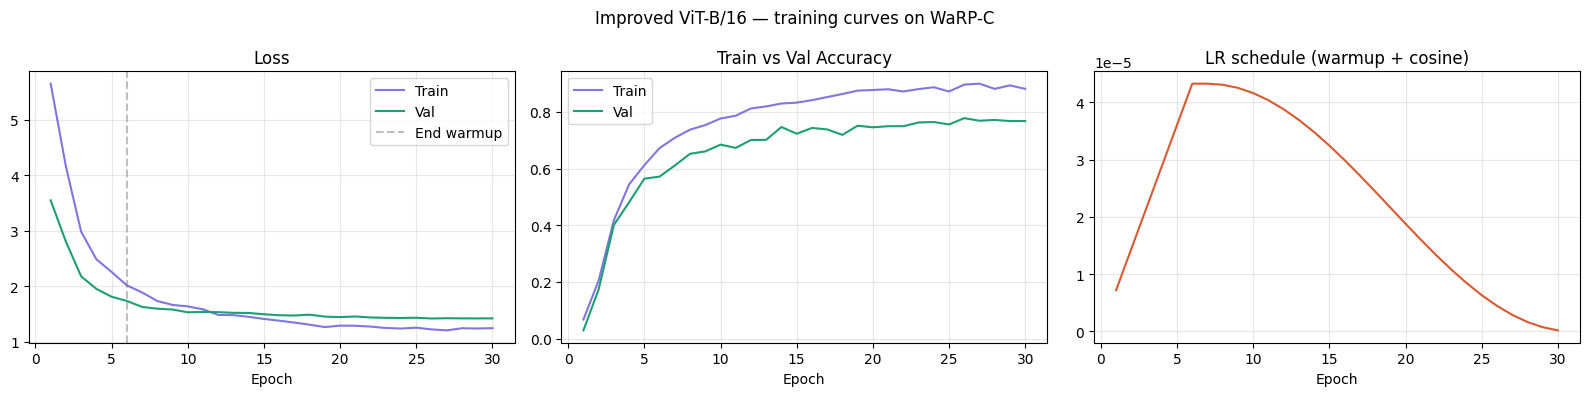

In [ ]:
# TRAINING CURVES

epochs_x = range(1, NUMBER_OF_EPOCHS + 1)    # x-axis: epoch numbers
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: training and validation loss
axes[0].plot(epochs_x, history['train_loss'], label='Train', color='#7F77DD')
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='#1D9E75')
axes[0].axvline(WARMUP_EPOCHS, color='gray', linestyle='--', alpha=0.5, label='End warmup')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot 2: training and validation accuracy
axes[1].plot(epochs_x, history['train_acc'], label='Train', color='#7F77DD')
axes[1].plot(epochs_x, history['val_acc'],   label='Val',   color='#1D9E75')
axes[1].set_title('Train vs Val Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Plot 3: learning rate schedule (warmup + cosine decay)
axes[2].plot(epochs_x, history['lr'], color='#D85A30')
axes[2].set_title('LR schedule (warmup + cosine)')
axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.suptitle('Improved ViT-B/16 — training curves on WaRP-C', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150)
plt.show()


In [ ]:
# TEST EVALUATION

# Load the best model weights saved during training
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("Running inference on test set")

all_probs  = []   # softmax probability vectors for each test image
all_preds  = []   # predicted class index for each test image
all_true   = []   # ground truth label for each test image

with torch.no_grad():   # no gradients needed during inference
    for images, labels in test_loader:
        images = images.to(device)
        logits = model(images)  # forward pass
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

import numpy as np
all_probs = np.array(all_probs)   # shape: (N, 28)
all_preds = np.array(all_preds)   # shape: (N,)
all_true  = np.array(all_true)    # shape: (N,)

print(f"Inference complete. Total test images: {len(all_true)}")

Running inference on test set
Inference complete. Total test images: 1551


In [ ]:
# FULL EVALUATION
test_accuracy  = (all_preds == all_true).mean()
test_precision = precision_score(all_true, all_preds, average='macro', zero_division=0)
test_recall = recall_score(all_true, all_preds, average='macro', zero_division=0)
test_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)

true_bin = label_binarize(all_true, classes=list(range(NUMBER_OF_CLASSES)))
test_auc = roc_auc_score(true_bin, all_probs, multi_class='ovr', average='macro')
test_map = average_precision_score(true_bin, all_probs, average='macro')

print("  IMPROVED ViT-B/16 - TEST SET RESULTS")
print(f"  Accuracy: {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall : {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"  AUC: {test_auc:.4f}")
print(f"  mAP: {test_map:.4f}")

print("\nPer-class report:")
print(classification_report(all_true, all_preds, target_names=class_names, digits=3))

  IMPROVED ViT-B/16 - TEST SET RESULTS
  Accuracy: 0.7711  (77.11%)
  Precision: 0.7523
  Recall : 0.8086
  F1-Score: 0.7678
  AUC: 0.9808
  mAP: 0.8491

Per-class report:
                         precision    recall  f1-score   support

            bottle-blue      0.760     0.702     0.730       104
       bottle-blue-full      0.735     0.837     0.783        43
          bottle-blue5l      0.699     0.903     0.788        72
     bottle-blue5l-full      0.759     0.917     0.830        24
            bottle-dark      0.934     0.895     0.914        95
       bottle-dark-full      0.714     0.882     0.789        34
           bottle-green      0.846     0.892     0.868        74
      bottle-green-full      0.795     0.912     0.849        34
            bottle-milk      0.717     0.754     0.735        57
       bottle-milk-full      0.731     0.905     0.809        21
      bottle-multicolor      0.650     0.464     0.542        28
bottle-multicolorv-full      0.615     0.762   

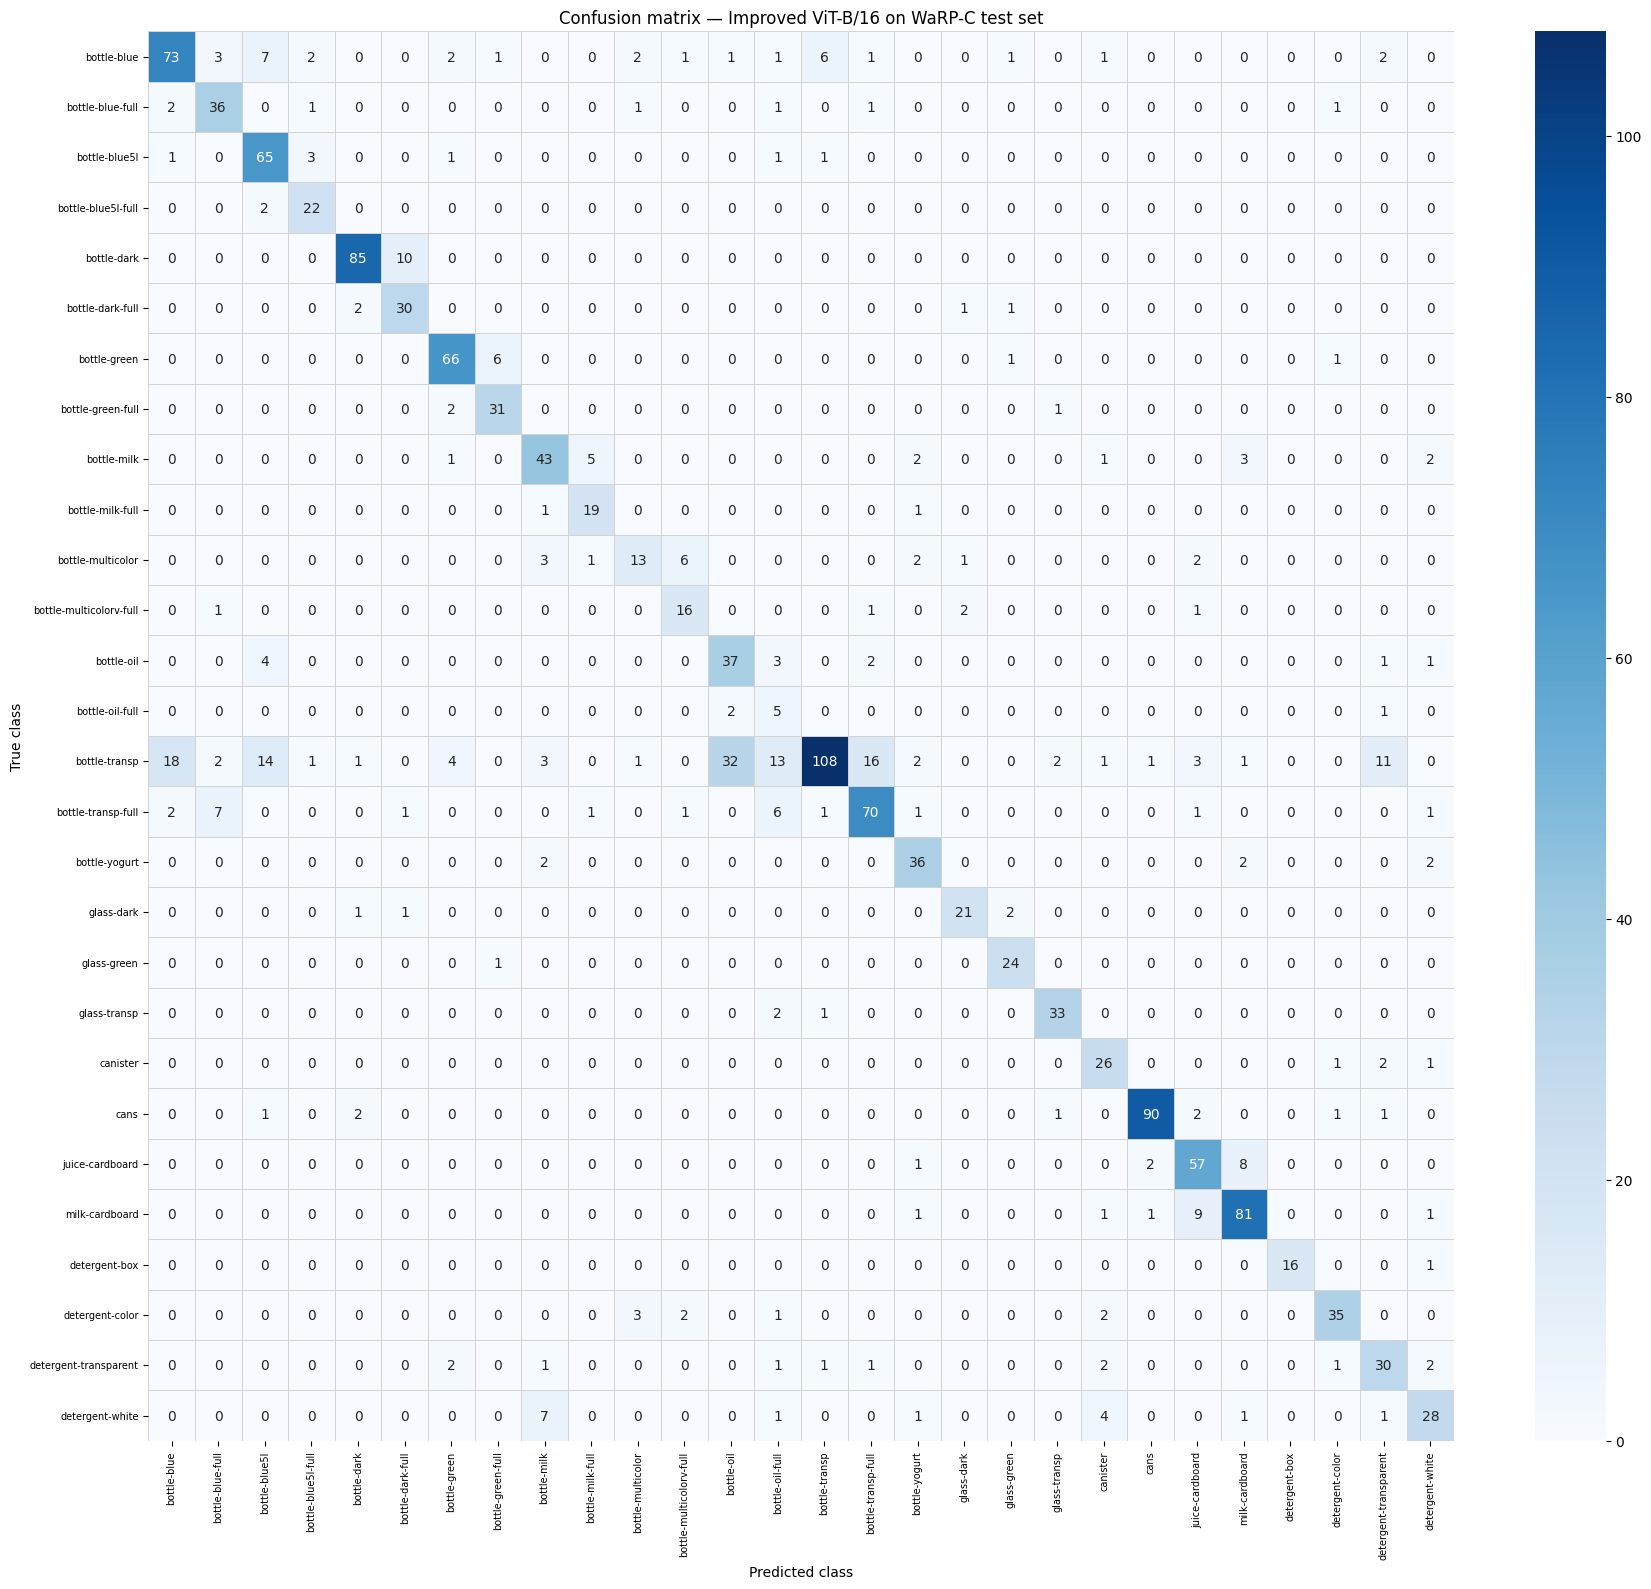

Saved confusion_matrix.png


In [ ]:
# CONFUSION MATRIX
conf_matrix = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.4, linecolor='lightgrey', ax=ax)
ax.set_xlabel('Predicted class'); ax.set_ylabel('True class')
ax.set_title('Confusion matrix — Improved ViT-B/16 on WaRP-C test set')
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrix.png', dpi=150)
plt.show()
print("Saved confusion_matrix.png")

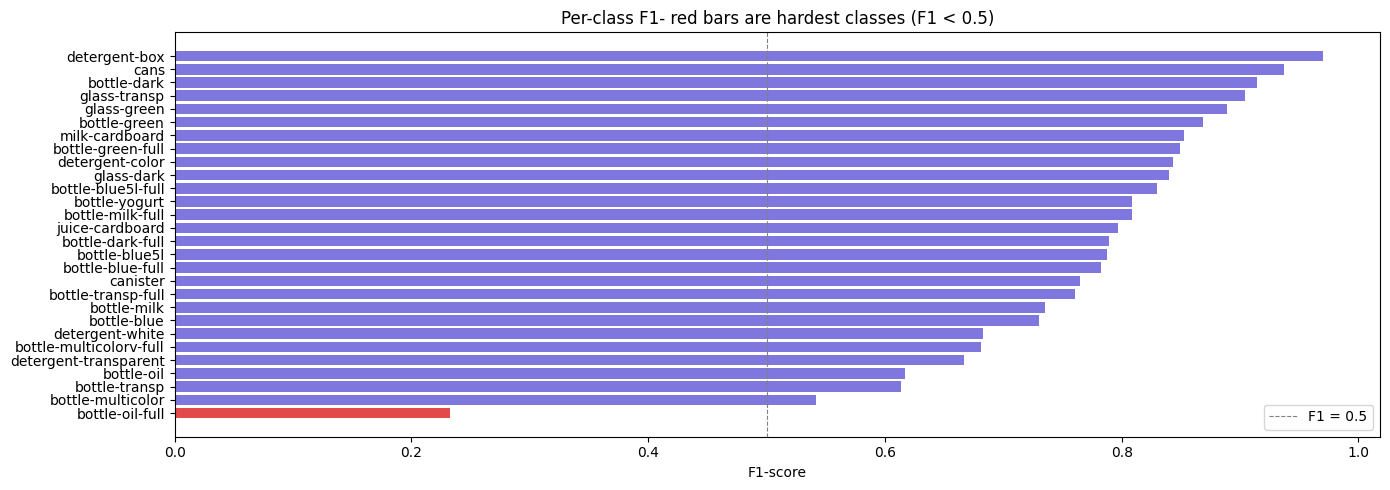

Saved per_class_f1.png


In [ ]:
# PER-CLASS F1 BAR CHART
per_class_f1  = f1_score(all_true, all_preds, average=None)
sorted_order  = np.argsort(per_class_f1)
sorted_names  = [class_names[i] for i in sorted_order]
sorted_scores = per_class_f1[sorted_order]
bar_colours   = ['#E24B4A' if s < 0.5 else '#7F77DD' for s in sorted_scores]

fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(sorted_names, sorted_scores, color=bar_colours)
ax.axvline(x=0.5, color='grey', linestyle='--', linewidth=0.8, label='F1 = 0.5')
ax.set_xlabel('F1-score')
ax.set_title('Per-class F1- red bars are hardest classes (F1 < 0.5)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_f1.png', dpi=150)
plt.show()
print("Saved per_class_f1.png")

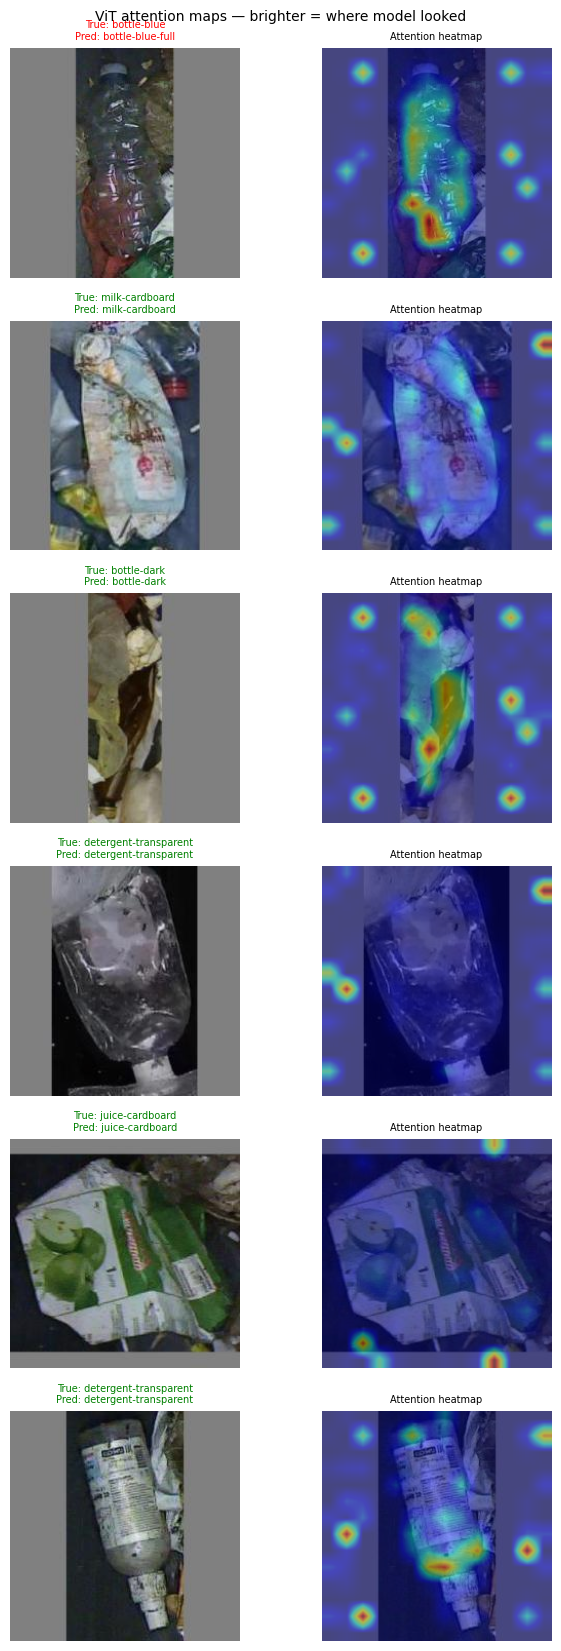

Saved attention_maps.png


In [ ]:
# ATTENTION MAP VISUALISATION

def get_attention_heatmap(model, image_tensor):
    captured = []
    def hook_fn(module, inp, out):
        x = inp[0]; B, N, C = x.shape
        qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, C // module.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k = qkv[0], qkv[1]
        attn = torch.softmax((q @ k.transpose(-2,-1)) / math.sqrt(q.shape[-1]), dim=-1)
        captured.append(attn.detach().cpu())
    hook = model.blocks[-1].attn.register_forward_hook(hook_fn)
    model.eval()
    with torch.no_grad(): model(image_tensor.unsqueeze(0).to(device))
    hook.remove()
    if not captured: return None
    cls_attn = captured[0][0].mean(0)[0, 1:]
    g = int(math.sqrt(cls_attn.shape[0]))
    hm = cls_attn.reshape(g, g).numpy()
    return (hm - hm.min()) / (hm.max() - hm.min() + 1e-8)


def show_attention_maps(model, dataset, num_images=6):
    idxs = random.sample(range(len(dataset)), num_images)
    fig, axes = plt.subplots(num_images, 2, figsize=(7, num_images * 2.8))
    fig.suptitle('ViT attention maps — brighter = where model looked', fontsize=10)
    mean_t = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std_t  = torch.tensor(IMAGENET_STD).view(3,1,1)
    for row, idx in enumerate(idxs):
        img_t, true_lbl = dataset[idx]
        with torch.no_grad():
            pred = model(img_t.unsqueeze(0).to(device)).argmax(1).item()
        hm = get_attention_heatmap(model, img_t)
        disp = (img_t * std_t + mean_t).clamp(0,1).permute(1,2,0).numpy()
        hm_up = np.array(Image.fromarray((hm*255).astype(np.uint8))
                           .resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR)) / 255.0
        col = 'green' if pred == true_lbl else 'red'
        axes[row,0].imshow(disp)
        axes[row,0].set_title(f'True: {class_names[true_lbl]}\nPred: {class_names[pred]}',
                               fontsize=7, color=col)
        axes[row,0].axis('off')
        axes[row,1].imshow(disp)
        axes[row,1].imshow(hm_up, cmap='jet', alpha=0.45)
        axes[row,1].set_title('Attention heatmap', fontsize=7)
        axes[row,1].axis('off')
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/attention_maps.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved attention_maps.png")

show_attention_maps(model, test_dataset, num_images=6)

In [ ]:
# POST-TRAINING INT8 QUANTISATION
def model_size_mb(m):
    buf = io.BytesIO(); torch.save(m.state_dict(), buf); return buf.tell()/1024**2

def cpu_speed(m, loader, n=20):
    m.eval(); m.to('cpu'); ts = []
    with torch.no_grad():
        for i, (imgs, _) in enumerate(loader):
            if i >= n: break
            t0 = time.perf_counter(); m(imgs)
            ts.append((time.perf_counter()-t0)/imgs.size(0)*1000)
    m.to(device); return float(np.mean(ts))

def cpu_accuracy(m, loader, n=30):
    m.eval(); m.to('cpu'); correct = total = 0
    with torch.no_grad():
        for i, (imgs, lbls) in enumerate(loader):
            if i >= n: break
            preds = m(imgs).argmax(1)
            correct += (preds == lbls).sum().item(); total += lbls.size(0)
    m.to(device); return correct/total

fp32 = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUMBER_OF_CLASSES)
fp32.load_state_dict(torch.load(best_model_path, map_location='cpu'))
fp32.eval()
int8 = torch.quantization.quantize_dynamic(fp32, {nn.Linear}, dtype=torch.qint8)

fp32_sz, fp32_sp, fp32_ac = model_size_mb(fp32), cpu_speed(fp32, test_loader), cpu_accuracy(fp32, test_loader)
int8_sz, int8_sp, int8_ac = model_size_mb(int8), cpu_speed(int8, test_loader), cpu_accuracy(int8, test_loader)

print(f"\n{'Metric':<22} {'FP32':>10}  {'INT8':>10}  {'Change':>10}")
print(f"{'Model size (MB)':<22} {fp32_sz:>10.1f}  {int8_sz:>10.1f}  {(int8_sz-fp32_sz)/fp32_sz*100:>+9.1f}%")
print(f"{'Accuracy':<22} {fp32_ac:>10.4f}  {int8_ac:>10.4f}  {(int8_ac-fp32_ac)*100:>+9.2f}pp")
print(f"{'Speed (ms/image)':<22} {fp32_sp:>10.2f}  {int8_sp:>10.2f}  {fp32_sp/int8_sp:>9.1f}x faster")


Metric                       FP32        INT8      Change
Model size (MB)             327.4        84.4      -74.2%
Accuracy                   0.8500      0.8688      +1.88pp
Speed (ms/image)           356.83      304.82        1.2x faster


In [ ]:
import numpy as np
# FINAL SUMMARY
print("  FINAL SUMMARY — Improved ViT-B/16 on WaRP-C")
print(f"  Model : {MODEL_NAME}")
print(f"  Image size : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"  Epochs : {NUMBER_OF_EPOCHS} (warmup={WARMUP_EPOCHS})")
print(f"  Best val acc: {best_val_accuracy:.4f}")
print(f"  Test Accuracy : {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  Test Precision : {test_precision:.4f}")
print(f"  Test Recall: {test_recall:.4f}")
print(f"  Test F1 : {test_f1:.4f}")
print(f"  Test AUC: {test_auc:.4f}")
print(f"  Test mAP: {test_map:.4f}")
print(f"\nOutputs saved to: {RESULTS_DIR}/")

  FINAL SUMMARY — Improved ViT-B/16 on WaRP-C
  Model : vit_base_patch16_224
  Image size : 224x224
  Epochs : 30 (warmup=6)
  Best val acc: 0.7779
  Test Accuracy : 0.7711  (77.11%)
  Test Precision : 0.7523
  Test Recall: 0.8086
  Test F1 : 0.7678
  Test AUC: 0.9808
  Test mAP: 0.8491

Outputs saved to: ./results_improved/


In [ ]:
#CLIP Zero-Shot Classifier
!pip install transformers -q

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]


Sample prompts:
  'a photo of a bottle blue waste item'
  'a photo of a bottle blue full waste item'
  'a photo of a bottle blue5l waste item'
  'a photo of a bottle blue5l full waste item'
  ... (28 total)

Running CLIP zero-shot on test set...
CLIP Zero-Shot Accuracy : 0.0052  (0.52%)
CLIP Zero-Shot F1 (macro): 0.0012
Inference speed : 40.4 images/sec


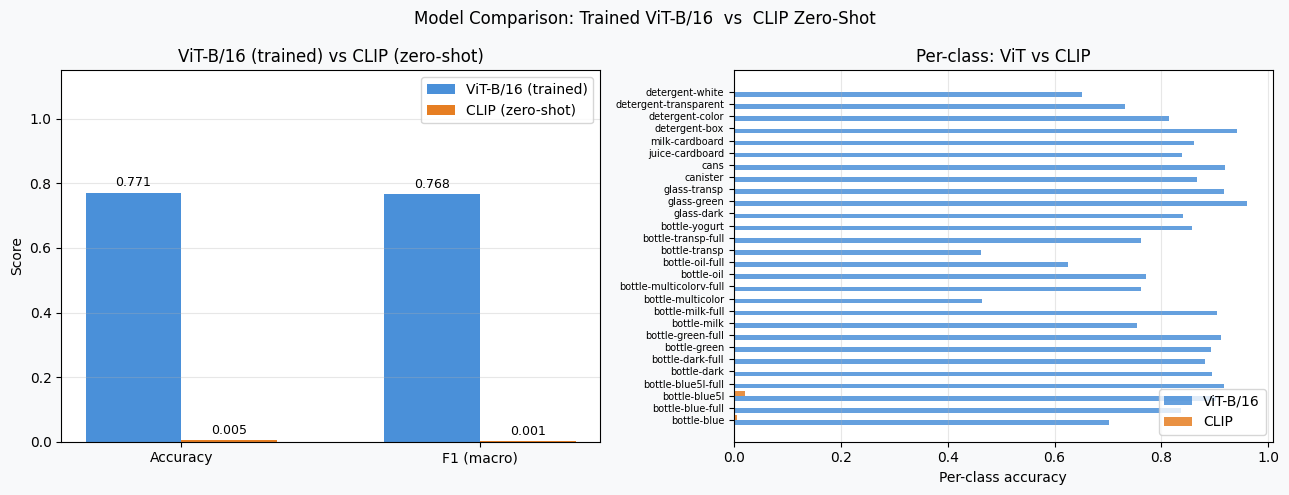

  MODEL COMPARISON SUMMARY
  Metric                      ViT-B/16 (trained)   CLIP (zero-shot)
  Accuracy                                0.7711             0.0052
  F1 (macro)                              0.7678             0.0012
  Params (M)                                86.6              151.3
  Training required              Yes (30 epochs)     No (zero-shot)
  Inference speed (img/s)                   40.4               40.4

Key takeaway:
  Trained ViT-B/16 benefits from task-specific fine-tuning on
  WaRP-C, giving higher accuracy on the 28 fine-grained classes.
  CLIP achieves this without ANY training, demonstrating the
  power of open-vocabulary vision-language models for waste
  classification — and can generalise to NEW categories not
  seen during training simply by changing the text prompts.


In [ ]:
#CLIP Zero-Shot Classification on WaRP-C
#   We use the 28 WaRP-C class names as text prompts and let CLIP match each test image to the most similar class description.
from transformers import CLIPProcessor, CLIPModel
from torch.utils.data import DataLoader
import torch, numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import accuracy_score, f1_score
import time

# Load CLIP model
clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device.type)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()

# Build text prompts from WaRP-C class names
def make_prompt(cls_name: str) -> str:
    name = cls_name.replace('-', ' ').replace('transp', 'transparent')
    return f"a photo of a {name} waste item"

text_prompts = [make_prompt(n) for n in class_names]
print(f"\nSample prompts:")
for p in text_prompts[:4]:
    print(f"  '{p}'")
print(f"  ... ({len(text_prompts)} total)")

# Pre-compute text embeddings once
with torch.no_grad():
    text_inputs  = clip_processor(text=text_prompts, return_tensors="pt",
                                   padding=True, truncation=True).to(device.type)
    text_features = clip_model.get_text_features(**text_inputs).pooler_output
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

# Zero-shot inference on test set
print("\nRunning CLIP zero-shot on test set...")

clip_preds  = []
clip_labels = []
clip_probs_all = []

# Use raw PIL images
from torchvision.datasets import ImageFolder
raw_test_dataset = ImageFolder(TEST_FOLDER)

t0 = time.time()
with torch.no_grad():
    for img, label in raw_test_dataset:
        # CLIP processor handles its own resize/normalise
        inputs = clip_processor(images=img, return_tensors="pt").to(device.type)
        img_features = clip_model.get_image_features(**inputs).pooler_output
        img_features = img_features / img_features.norm(dim=-1, keepdim=True)

        # Cosine similarity
        logits = (img_features @ text_features.T) * clip_model.logit_scale.exp()
        probs  = torch.softmax(logits, dim=-1)[0].cpu().numpy()

        clip_preds.append(int(probs.argmax()))
        clip_labels.append(label)
        clip_probs_all.append(probs)

clip_time = time.time() - t0
clip_preds  = np.array(clip_preds)
clip_labels = np.array(clip_labels)
clip_probs_all = np.array(clip_probs_all)

clip_accuracy = accuracy_score(clip_labels, clip_preds)
clip_f1       = f1_score(clip_labels, clip_preds, average='macro', zero_division=0)
clip_speed    = len(raw_test_dataset) / clip_time

print(f"CLIP Zero-Shot Accuracy : {clip_accuracy:.4f}  ({clip_accuracy*100:.2f}%)")
print(f"CLIP Zero-Shot F1 (macro): {clip_f1:.4f}")
print(f"Inference speed : {clip_speed:.1f} images/sec")


# Compare CLIP vs trained ViT
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#F8F9FA')

# Left: overall metric comparison bar chart
metrics      = ['Accuracy', 'F1 (macro)']
vit_scores   = [test_accuracy, test_f1]
clip_scores  = [clip_accuracy, clip_f1]
x = np.arange(len(metrics))
w = 0.32

bars1 = axes[0].bar(x - w/2, vit_scores,  w, label='ViT-B/16 (trained)', color='#4A90D9')
bars2 = axes[0].bar(x + w/2, clip_scores, w, label='CLIP (zero-shot)',   color='#E67E22')

for bar in bars1 + bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

axes[0].set_xticks(x); axes[0].set_xticklabels(metrics)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('ViT-B/16 (trained) vs CLIP (zero-shot)')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Right: per-class accuracy comparison
vit_per_class  = []
clip_per_class = []
for cls_idx in range(NUMBER_OF_CLASSES):
    mask = (np.array(all_true) == cls_idx)   # from ViT test evaluation
    if mask.sum() == 0:
        vit_per_class.append(0.0)
        clip_per_class.append(0.0)
        continue
    vit_per_class.append((np.array(all_preds)[mask] == cls_idx).mean())
    clip_per_class.append((clip_preds[clip_labels == cls_idx] == cls_idx).mean()
                           if (clip_labels == cls_idx).sum() > 0 else 0.0)

y_pos = np.arange(NUMBER_OF_CLASSES)
axes[1].barh(y_pos - 0.2, vit_per_class,  0.38, label='ViT-B/16', color='#4A90D9', alpha=0.85)
axes[1].barh(y_pos + 0.2, clip_per_class, 0.38, label='CLIP',     color='#E67E22', alpha=0.85)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(class_names, fontsize=7)
axes[1].set_xlabel('Per-class accuracy')
axes[1].set_title('Per-class: ViT vs CLIP')
axes[1].legend(loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Model Comparison: Trained ViT-B/16  vs  CLIP Zero-Shot', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/clip_vs_vit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#Summary table

print("  MODEL COMPARISON SUMMARY")
print(f"  {'Metric':<25} {'ViT-B/16 (trained)':>20} {'CLIP (zero-shot)':>18}")
print(f"  {'Accuracy':<25} {test_accuracy:>20.4f} {clip_accuracy:>18.4f}")
print(f"  {'F1 (macro)':<25} {test_f1:>20.4f} {clip_f1:>18.4f}")
print(f"  {'Params (M)':<25} {'86.6':>20} {'151.3':>18}")
print(f"  {'Training required':<25} {'Yes (30 epochs)':>20} {'No (zero-shot)':>18}")
print(f"  {'Inference speed (img/s)':<25} {len(raw_test_dataset)/clip_time:>20.1f} {clip_speed:>18.1f}")
print("\nKey takeaway:")
print("  Trained ViT-B/16 benefits from task-specific fine-tuning on")
print("  WaRP-C, giving higher accuracy on the 28 fine-grained classes.")
print("  CLIP achieves this without ANY training, demonstrating the")
print("  power of open-vocabulary vision-language models for waste")
print("  classification — and can generalise to NEW categories not")
print("  seen during training simply by changing the text prompts.")


Super-class coverage:
  bottle       (17 classes): ['bottle-blue', 'bottle-blue-full', 'bottle-blue5l', 'bottle-blue5l-full', 'bottle-dark', 'bottle-dark-full', 'bottle-green', 'bottle-green-full', 'bottle-milk', 'bottle-milk-full', 'bottle-multicolor', 'bottle-multicolorv-full', 'bottle-oil', 'bottle-oil-full', 'bottle-transp', 'bottle-transp-full', 'bottle-yogurt']
  can          ( 1 classes): ['cans']
  canister     ( 1 classes): ['canister']
  detergent    ( 4 classes): ['detergent-box', 'detergent-color', 'detergent-transparent', 'detergent-white']
  glass        ( 3 classes): ['glass-dark', 'glass-green', 'glass-transp']
  other        ( 2 classes): not targeted
  WASTE MATERIAL DETECTOR
  Upload an image of any waste item below.


Saving download.jfif to download.jfif


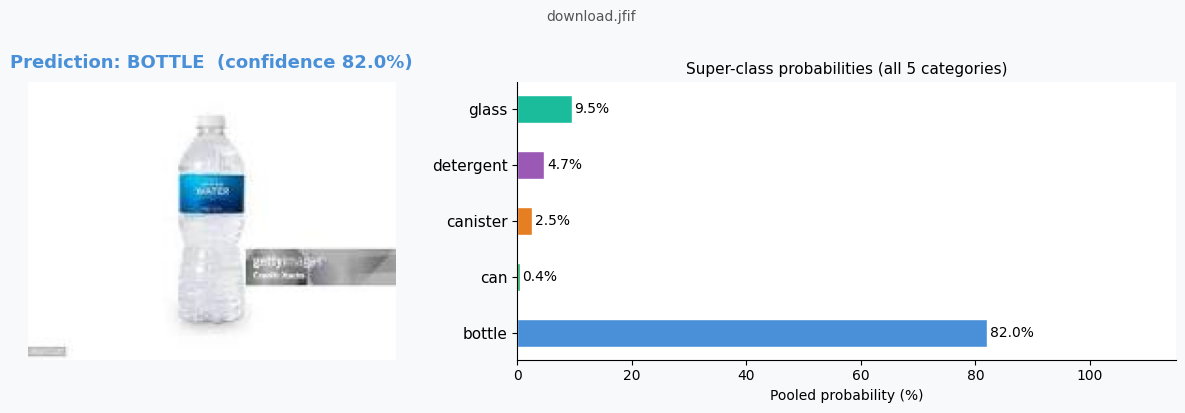


Top-3 super-class predictions:
  1 BOTTLE         82.0%
  2 GLASS           9.5%
  3 DETERGENT       4.7%
  RESULT =BOTTLE


In [ ]:
# WASTE MATERIAL DETECTOR- bottle / can / canister / detergent / glass
# Uses the trained ViT to classify any uploaded
from google.colab import files as colab_files
import torch, torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import io

SUPER_CLASSES = ['bottle', 'can', 'canister', 'detergent', 'glass']
CONFIDENCE_THRESHOLD = 0.15

def assign_super_class(cls_name: str) -> str:
    name = cls_name.lower()
    if name.startswith('bottle'):   return 'bottle'
    if name in ('cans', 'can'):     return 'can'
    if name == 'canister':          return 'canister'
    if name.startswith('detergent'):return 'detergent'
    if name.startswith('glass'):    return 'glass'
    return 'other'

# Map every fine-grained WaRP-C index to a super-class
super_class_indices = {sc: [] for sc in SUPER_CLASSES + ['other']}
for idx, name in enumerate(class_names):
    super_class_indices[assign_super_class(name)].append(idx)

print('Super-class coverage:')
for sc in SUPER_CLASSES:
    names = [class_names[i] for i in super_class_indices[sc]]
    print(f'  {sc:12s} ({len(names):2d} classes): {names}')
print(f'  {"other":12s} ({len(super_class_indices["other"]):2d} classes): not targeted')


# Inference

infer_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def predict_super_class(pil_image: Image.Image):
    """
    Run the best available model on an image.
    Returns:
        best_sc   : top super-class string
        pooled    : {super-class: pooled_probability}
        top3      : [(fine-grained class name, prob), ...] top 3
    """
    # Load best checkpoint for most accurate inference
    inference_model = timm.create_model(
        MODEL_NAME, pretrained=False, num_classes=NUMBER_OF_CLASSES
    ).to(device)
    inference_model.load_state_dict(
        torch.load(best_model_path, map_location=device)
    )
    inference_model.eval()

    tensor = infer_transform(pil_image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(inference_model(tensor), dim=1)[0].cpu().numpy()

    # Pool fine-grained probs into super-classes
    pooled = {
        sc: float(probs[super_class_indices[sc]].sum())
        for sc in SUPER_CLASSES + ['other']
    }

    best_sc = max(SUPER_CLASSES, key=lambda sc: pooled[sc])
    if pooled[best_sc] < CONFIDENCE_THRESHOLD:
        best_sc = 'other'

    top3 = [(class_names[i], float(probs[i]))
            for i in np.argsort(probs)[::-1][:3]]

    return best_sc, pooled, top3


# Visualisation
SUPER_CLASS_OBJECTS = {
    'bottle':    '#4A90D9',
    'can':       '#27AE60',
    'canister':  '#E67E22',
    'detergent': '#9B59B6',
    'glass':     '#1ABC9C',
    'other':     '#95A5A6',
}


def visualise_prediction(pil_image, best_sc, pooled, top3, title='Uploaded image'):
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4),
                                          gridspec_kw={'width_ratios': [1, 1.6]})
    fig.patch.set_facecolor('#F8F9FA')

    # Left: image + label
    ax_img.imshow(pil_image)
    ax_img.axis('off')
    colour = SUPER_CLASS_OBJECTS[best_sc]

    ax_img.set_title(
        f"Prediction: {best_sc.upper()}  "
        f"(confidence {pooled.get(best_sc, 0)*100:.1f}%)",
        fontsize=13, fontweight='bold', color=colour, pad=10
    )

    # all 5 super-class probability bars
    sc_probs  = [pooled[sc] * 100 for sc in SUPER_CLASSES]
    bar_cols  = [SUPER_CLASS_OBJECTS[sc] for sc in SUPER_CLASSES]
    bars = ax_bar.barh(SUPER_CLASSES, sc_probs, color=bar_cols,
                        edgecolor='white', height=0.5)
    for bar, prob in zip(bars, sc_probs):
        ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                    f'{prob:.1f}%', va='center', fontsize=10)
    ax_bar.set_xlim(0, 115)
    ax_bar.set_xlabel('Pooled probability (%)', fontsize=10)
    ax_bar.set_title('Super-class probabilities (all 5 categories)', fontsize=11)
    ax_bar.spines[['top', 'right']].set_visible(False)
    ax_bar.tick_params(axis='y', labelsize=11)

    plt.suptitle(title, fontsize=10, color='#555555', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/waste_detector_prediction.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Print super-class level only (no fine-grained names)
    print('\nTop-3 super-class predictions:')

    sc_scores = sorted(
        [(sc, pooled[sc]) for sc in SUPER_CLASSES],
        key=lambda x: x[1], reverse=True
    )
    for rank, (sc, prob) in enumerate(sc_scores[:3], 1):

        print(f'  {rank} {sc.upper():<12}  {prob*100:5.1f}%')


# Upload & run
print('  WASTE MATERIAL DETECTOR')
print('  Upload an image of any waste item below.')

uploaded = colab_files.upload()

for filename, file_bytes in uploaded.items():
    pil_img = Image.open(io.BytesIO(file_bytes)).convert('RGB')
    best_sc, pooled, top3 = predict_super_class(pil_img)
    visualise_prediction(pil_img, best_sc, pooled, top3, title=filename)

    print(f"  RESULT ={best_sc.upper()}")
